In [26]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import json

PROJECT_DIR   = "/content/drive/MyDrive/DLP2"
PROCESSED_DIR = os.path.join(PROJECT_DIR, "data/processed")
MODELS_DIR    = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR   = os.path.join(PROJECT_DIR, "results")
FIGURES_DIR   = os.path.join(PROJECT_DIR, "figures")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

X_train = np.load(os.path.join(PROCESSED_DIR, "X_train.npy"))
X_val   = np.load(os.path.join(PROCESSED_DIR, "X_val.npy"))
X_test  = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))
y_train = np.load(os.path.join(PROCESSED_DIR, "y_train.npy"))
y_val   = np.load(os.path.join(PROCESSED_DIR, "y_val.npy"))
y_test  = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))

with open(os.path.join(PROCESSED_DIR, "activity_labels.json"), "r") as f:
    activity_labels = json.load(f)

print("X_train:", X_train.shape)
print("X_val:",   X_val.shape)
print("X_test:",  X_test.shape)
print(activity_labels)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X_train: (5881, 128, 9)
X_val: (1471, 128, 9)
X_test: (2947, 128, 9)
{'0': 'WALKING', '1': 'WALKING_UPSTAIRS', '2': 'WALKING_DOWNSTAIRS', '3': 'SITTING', '4': 'STANDING', '5': 'LAYING'}


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

TIME_STEPS   = X_train.shape[1]   # 128
NUM_CHANNELS = X_train.shape[2]   # 9
NUM_CLASSES  = len(activity_labels)
INPUT_SHAPE  = (TIME_STEPS, NUM_CHANNELS)

print("Input shape:", INPUT_SHAPE)
print("Number of classes:", NUM_CLASSES)
print("GPU:", tf.config.list_physical_devices('GPU'))

Input shape: (128, 9)
Number of classes: 6
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [28]:
ae_input = layers.Input(shape=INPUT_SHAPE)

# Encoder
enc = layers.Conv1D(64, 3, activation='relu', padding='same')(ae_input)
enc = layers.MaxPooling1D(2)(enc)
enc = layers.Conv1D(128, 3, activation='relu', padding='same')(enc)
encoded = layers.MaxPooling1D(2)(enc)   # (None, 32, 128)

# Decoder
dec = layers.Conv1D(128, 3, activation='relu', padding='same')(encoded)
dec = layers.UpSampling1D(2)(dec)
dec = layers.Conv1D(64, 3, activation='relu', padding='same')(dec)
dec = layers.UpSampling1D(2)(dec)
decoded = layers.Conv1D(NUM_CHANNELS, 3, activation='linear', padding='same')(dec)

autoencoder = keras.Model(ae_input, decoded, name="autoencoder")
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

ae_history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=30,
    batch_size=64,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

# Encoder'ı ayır ve dondur
encoder = keras.Model(ae_input, encoded, name="encoder")
for layer in encoder.layers:
    layer.trainable = False

print("Encoder output shape:", encoder.output_shape)

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 128, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 32, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 64, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 128, 9)         │         1,737 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,153 (399.04 KB)

 Trainable params: 102,153 (399.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.2005 - val_loss: 0.0826
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0689 - val_loss: 0.0582
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0530 - val_loss: 0.0479
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0458 - val_loss: 0.0429
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0403 - val_loss: 0.0394
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0377 - val_loss: 0.0347
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0338 - val_loss: 0.0326
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0329 - val_loss: 0.0306
Epoch 9/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0312 - val_loss: 0.0343
Epoch 10/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0295 - val_loss: 0.0361
Epoch 11/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0277 - val_loss: 0.0276
Epoch 12/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0275 - val_l

In [29]:
def build_exp3_model(learning_rate=1e-3):
    """
    Exp 3: Encoder(frozen) → Conv1D → GlobalAveragePooling → Dense → Output
    GRU YOK, BatchNorm/Dropout YOK
    """
    enc_out = encoder.output   # (None, 32, 128)

    x = layers.Conv1D(64, 3, activation='relu', padding='same')(enc_out)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(64, activation='relu')(x)
    output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(encoder.input, output, name="Exp3_AE_CNN")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_exp3 = build_exp3_model()
model_exp3.summary()

Model: "Exp3_AE_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 128, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 32, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 16, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,486 (330.02 KB)

 Trainable params: 57,990 (226.52 KB)

 Non-trainable params: 26,496 (103.50 KB)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.7344 - loss: 0.7165 - val_accuracy: 0.8851 - val_loss: 0.3350
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9102 - loss: 0.2416 - val_accuracy: 0.9205 - val_loss: 0.1939
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9330 - loss: 0.1738 - val_accuracy: 0.9490 - val_loss: 0.1551
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9405 - loss: 0.1442 - val_accuracy: 0.9497 - val_loss: 0.1154
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9466 - loss: 0.1254 - val_accuracy: 0.9483 - val_loss: 0.1113
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9486 - loss: 0.1159 - val_accuracy: 0.9443 - val_loss: 0.1439
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9509 - loss: 0.1136 - val_accuracy: 0.9517 - val_loss: 0.1061
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9500 - loss: 0.1087 - val_accuracy: 0.9653 - val_loss

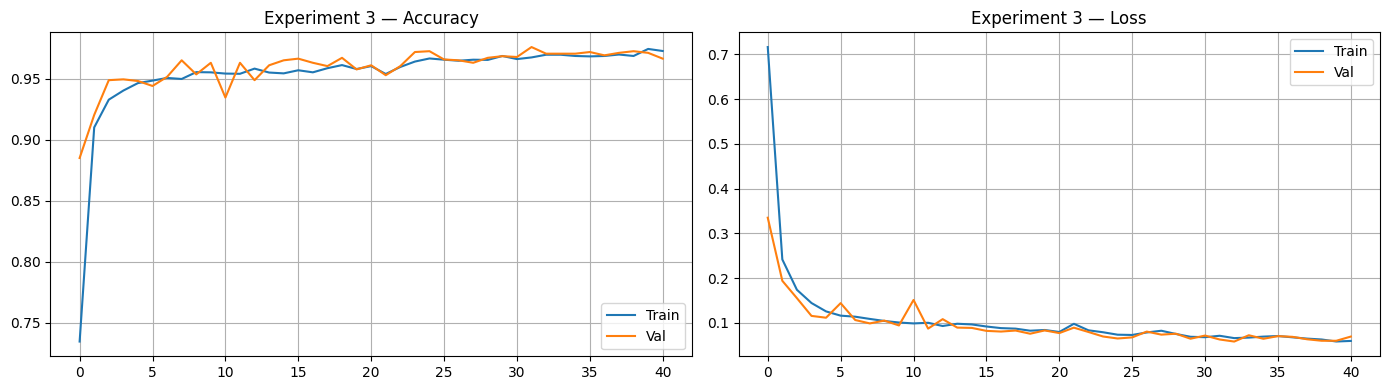

In [30]:
callbacks_exp3 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8, restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(MODELS_DIR, "exp3_best.keras"),
        monitor='val_loss', save_best_only=True
    )
]

history_exp3 = model_exp3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks_exp3,
    verbose=1
)

# Training curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history_exp3.history['accuracy'], label='Train')
ax1.plot(history_exp3.history['val_accuracy'], label='Val')
ax1.set_title('Experiment 3 — Accuracy')
ax1.legend(); ax1.grid(True)

ax2.plot(history_exp3.history['loss'], label='Train')
ax2.plot(history_exp3.history['val_loss'], label='Val')
ax2.set_title('Experiment 3 — Loss')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "exp3_training_curves.png"), dpi=300, bbox_inches="tight")
plt.show()

Test Accuracy: 0.9206
Test Loss:     0.4559
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
                    precision    recall  f1-score   support

           WALKING     1.0000    0.9718    0.9857       496
  WALKING_UPSTAIRS     0.9177    0.9469    0.9321       471
WALKING_DOWNSTAIRS     0.9190    1.0000    0.9578       420
           SITTING     0.7965    0.8452    0.8202       491
          STANDING     0.8931    0.8008    0.8444       532
            LAYING     1.0000    0.9758    0.9877       537

          accuracy                         0.9206      2947
         macro avg     0.9211    0.9234    0.9213      2947
      weighted avg     0.9221    0.9206    0.9204      2947



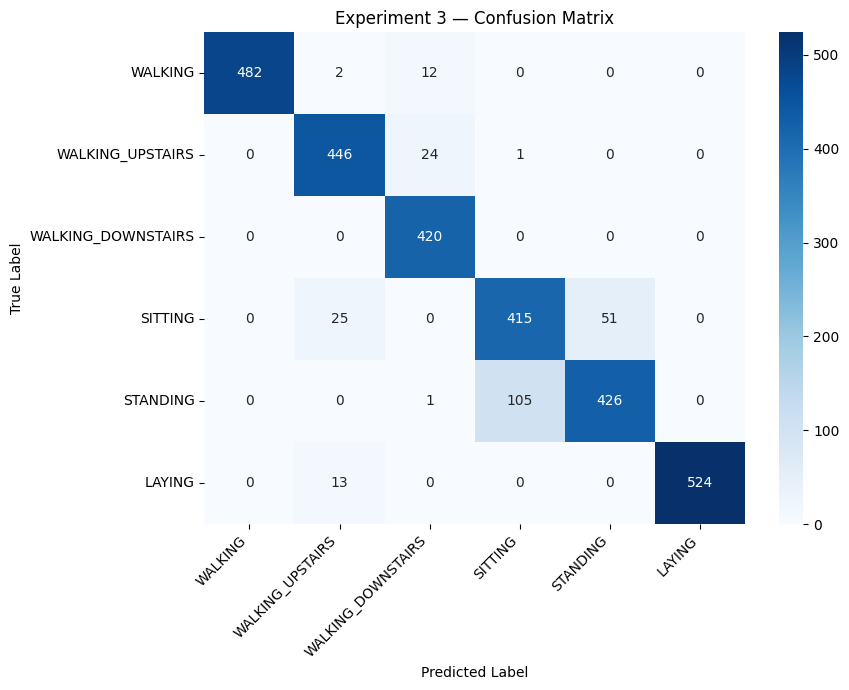

{'experiment': 'Experiment 3 - Autoencoder + CNN', 'model': 'Encoder(frozen) + Conv1D + GlobalAvgPool + Dense', 'input_shape': [128, 9], 'num_classes': 6, 'optimizer': 'Adam', 'learning_rate': 0.001, 'batch_size': 64, 'epochs_trained': 41, 'test_loss': 0.45588287711143494, 'test_accuracy': 0.9205971956253052, 'total_parameters': 84486}


In [31]:
test_loss3, test_acc3 = model_exp3.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc3:.4f}")
print(f"Test Loss:     {test_loss3:.4f}")

y_pred3 = np.argmax(model_exp3.predict(X_test), axis=1)
target_names = [activity_labels[str(i)] for i in range(NUM_CLASSES)]

report3 = classification_report(y_test, y_pred3, target_names=target_names, digits=4)
print(report3)

with open(os.path.join(RESULTS_DIR, "exp3_classification_report.txt"), "w") as f:
    f.write(report3)

# Confusion matrix
cm3 = confusion_matrix(y_test, y_pred3)
plt.figure(figsize=(9, 7))
sns.heatmap(cm3, annot=True, fmt="d", xticklabels=target_names,
            yticklabels=target_names, cmap="Blues")
plt.title('Experiment 3 — Confusion Matrix')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "exp3_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

# Model kaydet
model_exp3.save(os.path.join(MODELS_DIR, "exp3_final.keras"))

# JSON kaydet
results3 = {
    "experiment": "Experiment 3 - Autoencoder + CNN",
    "model": "Encoder(frozen) + Conv1D + GlobalAvgPool + Dense",
    "input_shape": list(INPUT_SHAPE),
    "num_classes": NUM_CLASSES,
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "batch_size": 64,
    "epochs_trained": len(history_exp3.history["loss"]),
    "test_loss": float(test_loss3),
    "test_accuracy": float(test_acc3),
    "total_parameters": model_exp3.count_params()
}
with open(os.path.join(RESULTS_DIR, "exp3_results.json"), "w") as f:
    json.dump(results3, f, indent=4)

print(results3)